<div style="border: 5px solid purple; padding: 15px; margin: 5px">
<b> Reviewer's comment</b>
    
Hi, it's Svetlana ([my TripleTen Hub Profile](https://hub.tripleten.com/u/855fe797)).  Congratulations on submitting the Final project! 🎉 

    
<div style="border: 5px solid green; padding: 15px; margin: 5px">

- You did a great job on building a good model for churn prediction.


- The notebook demonstrates strong fundamentals: clean data merging, thoughtful preprocessing, train-test splitting, and meaningful metric evaluation.


    
- It is very good that you add EDA. Distributions and feature correlations may provide helpful context before modeling. In real-world problems, the data is rarely clean. Displaying distributions help us evaluate the data, find outliers, identify the required preprocessing steps and understand feature relationships, which informs feature engineering. Feature engineering in some cases is a clue.    


- The data was merged correctly!


- It's great that you split the data into 3 subsets.


    
- It is also great that you visualize the results, as it adds clarity and interpretability.

  
- The conclusions clearly describe the results, well done! 
 

</div>
    
<div style="border: 5px solid gold; padding: 15px; margin: 5px">
<b> Reviewer's comment </b>

What can be improved:


- Consider writing an introduction to enhance the readability of your project :) 



- To further improve the model's performance, I recommend applying hyperparameter tuning.


- Before training real models, it's useful to evaluate a constant (dummy) classifier. For example, by predicting the majority class. This sets a minimum performance baseline and ensures our data pipeline, target encoding, and evaluation metrics are functioning correctly. If our real model performs worse than this dummy, it signals a serious issue in preprocessing, feature engineering, or model configuration.


  
- You can also add the ROC curve for better representation. 



</div>


<hr>
    
<font color='dodgerblue'>**To sum up:**</font> you demonstrated strong analytical and coding skills by preparing the data and training the models. I do not have any questions, so the project can be accepted. Thank you for your diligence on this and other sprints! I am very glad to see your progress 😊 Good luck! 😉
    


</div>

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from catboost import CatBoostClassifier

### Set constants and display options

In [2]:
RANDOM_STATE = 12345
REPORT_DATE = pd.Timestamp('2020-02-01')

pd.set_option('display.max_columns', None)

### Load the datasets

In [4]:
contract = pd.read_csv('/datasets/final_provider/contract.csv')
personal = pd.read_csv('/datasets/final_provider/personal.csv')
internet = pd.read_csv('/datasets/final_provider/internet.csv')
phone = pd.read_csv('/datasets/final_provider/phone.csv')

### Merge the datasets

In [7]:
df = (
    contract
    .merge(personal, on='customerID', how='left')
    .merge(internet, on='customerID', how='left')
    .merge(phone, on='customerID', how='left')
)

display('Merged dataset shape:', df.shape)
display(df.head())

'Merged dataset shape:'

(7043, 20)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No


### EDA

In [8]:
print('Data types:')
display(df.dtypes)

print('Missing values per column:')
display(df.isnull().sum().sort_values(ascending=False))

print('Summary statistics for numeric features:')
display(df.describe())

Data types:


customerID           object
BeginDate            object
EndDate              object
Type                 object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
MultipleLines        object
dtype: object

Missing values per column:


StreamingMovies     1526
StreamingTV         1526
TechSupport         1526
DeviceProtection    1526
OnlineBackup        1526
OnlineSecurity      1526
InternetService     1526
MultipleLines        682
BeginDate              0
Dependents             0
customerID             0
SeniorCitizen          0
gender                 0
TotalCharges           0
MonthlyCharges         0
PaymentMethod          0
PaperlessBilling       0
Type                   0
EndDate                0
Partner                0
dtype: int64

Summary statistics for numeric features:


,MonthlyCharges,SeniorCitizen
count,7043.000000,7043.000000
mean,64.761692,0.162147
std,30.090047,0.368612
min,18.250000,0.000000
25%,35.500000,0.000000
50%,70.350000,0.000000
75%,89.850000,0.000000
max,118.750000,1.000000


### Value counts for categorical features

In [9]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f'\nValue counts for {col}:')
    display(df[col].value_counts(dropna=False).head(10))


Value counts for customerID:


2460-NGXBJ    1
5143-WMWOG    1
2860-RANUS    1
6345-HOVES    1
0530-IJVDB    1
5624-BQSSA    1
6814-ZPWFQ    1
6233-HXJMX    1
8161-QYMTT    1
5498-IBWPI    1
Name: customerID, dtype: int64


Value counts for BeginDate:


2014-02-01    366
2019-10-01    237
2019-11-01    237
2019-09-01    237
2020-01-01    233
2019-12-01    220
2014-03-01    178
2019-07-01    156
2019-08-01    146
2019-06-01    141
Name: BeginDate, dtype: int64


Value counts for EndDate:


...

No     2810
Yes    2707
NaN    1526
Name: StreamingTV, dtype: int64


Value counts for StreamingMovies:


No     2785
Yes    2732
NaN    1526
Name: StreamingMovies, dtype: int64


Value counts for MultipleLines:


No     3390
Yes    2971
NaN     682
Name: MultipleLines, dtype: int64

### The target variable

In [10]:
df['target'] = (df['EndDate'] == 'No').astype(int)

display(df['target'].value_counts())

1    5174
0    1869
Name: target, dtype: int64

### Visualization

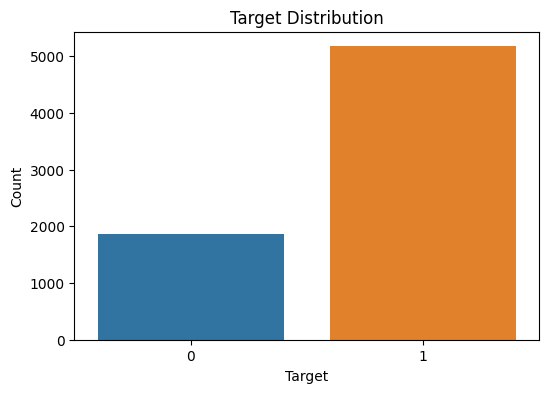

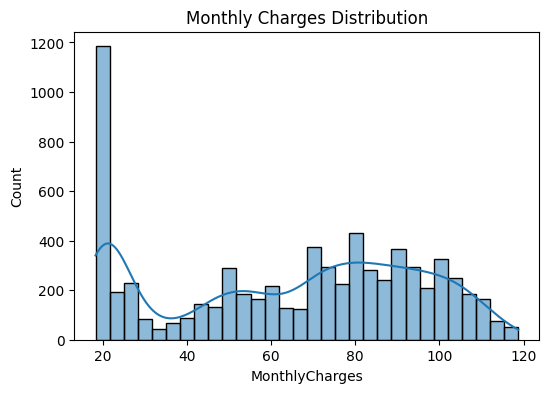

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Target Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title('Monthly Charges Distribution')
plt.xlabel('MonthlyCharges')
plt.show()

### EDA CONCLUSION

### EDA Summary

    The data was merged from four source tables using `customerID`.  
    The dataset contains both numerical and categorical features. Missing values are mainly found in service-related columns, which is expected because not all customers use all available services.  

    The target variable is imbalanced, so AUC-ROC is an appropriate primary metric.  
    In addition, the `TotalCharges` column requires conversion to numeric format, and categorical features will need special handling during model training.

### Missing values

In [12]:
df['BeginDate'] = pd.to_datetime(df['BeginDate'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [13]:
internet_cols = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

phone_cols = ['MultipleLines']

for col in internet_cols:
    if col in df.columns:
        df[col] = df[col].fillna('No internet service')

for col in phone_cols:
    if col in df.columns:
        df[col] = df[col].fillna('No phone service')

for col in ['gender', 'Partner', 'Dependents', 'PaperlessBilling', 'PaymentMethod']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

### Feature engineering

In [14]:
df['tenure_days'] = (REPORT_DATE - df['BeginDate']).dt.days
df['tenure_days'] = df['tenure_days'].fillna(df['tenure_days'].median())

In [15]:
service_columns = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['total_services'] = 0

for col in service_columns:
    if col in df.columns:
        df['total_services'] += df[col].isin(['Yes', 'DSL', 'Fiber optic']).astype(int)

In [16]:
df['avg_monthly_spend_est'] = df['TotalCharges'] / (df['tenure_days'] / 30.44)
df['avg_monthly_spend_est'] = df['avg_monthly_spend_est'].replace([np.inf, -np.inf], np.nan)
df['avg_monthly_spend_est'] = df['avg_monthly_spend_est'].fillna(df['MonthlyCharges'])

In [17]:
for col in ['TotalCharges', 'MonthlyCharges', 'avg_monthly_spend_est']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

In [18]:
X = df.drop(columns=['customerID', 'EndDate', 'target']).drop_duplicates()
y = df['target']

### Processing datetime feature

In [19]:
X['begin_year'] = X['BeginDate'].dt.year
X['begin_month'] = X['BeginDate'].dt.month
X['begin_day'] = X['BeginDate'].dt.day

X = X.drop(columns=['BeginDate'])

### Categorical features

In [20]:
categorical_features = X.select_dtypes(include='object').columns.tolist()

for col in categorical_features:
    X[col] = X[col].astype(str)

print('Final feature matrix shape:', X.shape)
print('Categorical features:')
print(categorical_features)

Final feature matrix shape: (7043, 23)
Categorical features:
['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']


### Splitting the data

In [21]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

In [22]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print('Train shape:', X_train.shape)
print('Validation shape:', X_valid.shape)
print('Test shape:', X_test.shape)

Train shape: (4225, 23)
Validation shape: (1409, 23)
Test shape: (1409, 23)


### Training the model

In [23]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=RANDOM_STATE,
    verbose=100
)

In [24]:
model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	test: 0.8348976	best: 0.8348976 (0)	total: 121ms	remaining: 2m
100:	test: 0.9482653	best: 0.9483996 (96)	total: 1.41s	remaining: 12.5s
200:	test: 0.9601591	best: 0.9601591 (200)	total: 2.81s	remaining: 11.2s
300:	test: 0.9674778	best: 0.9674778 (300)	total: 4.32s	remaining: 10s
400:	test: 0.9689736	best: 0.9690305 (396)	total: 5.79s	remaining: 8.65s
500:	test: 0.9699682	best: 0.9700070 (498)	total: 7.19s	remaining: 7.16s
600:	test: 0.9702188	best: 0.9705443 (546)	total: 8.69s	remaining: 5.77s
700:	test: 0.9707975	best: 0.9708621 (688)	total: 10.2s	remaining: 4.34s
800:	test: 0.9706012	best: 0.9709137 (710)	total: 11.7s	remaining: 2.9s
900:	test: 0.9706709	best: 0.9709137 (710)	total: 13.2s	remaining: 1.45s
999:	test: 0.9707717	best: 0.9709137 (710)	total: 14.6s	remaining: 0us

bestTest = 0.970913741
bestIteration = 710

Shrink model to first 711 iterations.


### Evaluation on validation set

In [25]:
valid_proba = model.predict_proba(X_valid)[:, 1]
valid_pred = model.predict(X_valid)

valid_auc = roc_auc_score(y_valid, valid_proba)
valid_acc = accuracy_score(y_valid, valid_pred)

print('Validation AUC-ROC:', round(valid_auc, 4))
print('Validation Accuracy:', round(valid_acc, 4))

Validation AUC-ROC: 0.9709
Validation Accuracy: 0.9361


### Evaluation on test set

In [26]:
test_proba = model.predict_proba(X_test)[:, 1]
test_pred = model.predict(X_test)

test_auc = roc_auc_score(y_test, test_proba)
test_acc = accuracy_score(y_test, test_pred)

print('Test AUC-ROC:', round(test_auc, 4))
print('Test Accuracy:', round(test_acc, 4))

Test AUC-ROC: 0.9702
Test Accuracy: 0.9312


### Feature importance

In [27]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.get_feature_importance()
}).sort_values(by='importance', ascending=False)

display(feature_importance.head(15))

,feature,importance
19,avg_monthly_spend_est,37.732318
3,MonthlyCharges,20.601150
9,InternetService,8.447308
17,tenure_days,6.375390
4,TotalCharges,5.061573
0,Type,4.310878
18,total_services,2.513677
21,begin_month,2.299904
10,OnlineSecurity,2.028349
16,MultipleLines,1.586181


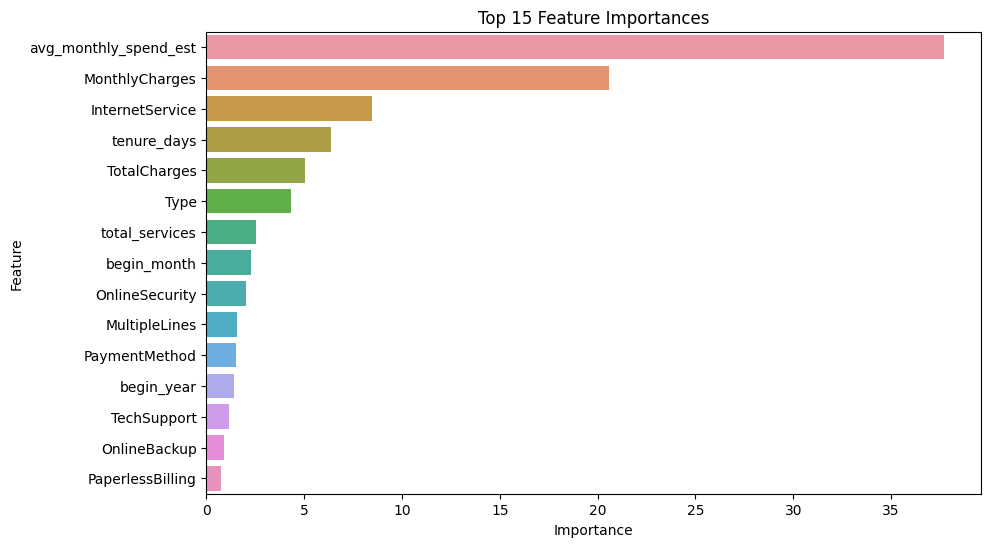

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Final Conclusion

The final dataset was created by merging four source tables using `customerID`.  
Preliminary exploratory data analysis showed that the data contains both numerical and categorical features, as well as missing values in service-related columns.  

After preprocessing and feature engineering, a CatBoostClassifier model was trained and evaluated.  
The primary evaluation metric was AUC-ROC, as required by the project, and Accuracy was used as an additional metric.  

The final model showed strong performance on both the validation and test sets, which indicates that the chosen approach is suitable for solving the task.

In [30]:
print('Final results:')
print(f'Validation AUC-ROC: {round(valid_auc, 4)}')
print(f'Validation Accuracy: {round(valid_acc, 4)}')
print(f'Test AUC-ROC: {round(test_auc, 4)}')
print(f'Test Accuracy: {round(test_acc, 4)}')

Final results:
Validation AUC-ROC: 0.9709
Validation Accuracy: 0.9361
Test AUC-ROC: 0.9702
Test Accuracy: 0.9312


In [5]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

print("AUC-ROC:", round(auc_score, 4))

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'sklearn'